# Proyecto Rappi: análisis de variables relevantes para predecir el tiempo de entrega

Este notebook ayuda a identificar qué columnas aportan valor real para predecir el tiempo de entrega, limpiar variables innecesarias y visualizar las relaciones más importantes antes de entrenar un modelo.

Objetivo principal: estimar el tiempo de entrega en minutos utilizando factores observables antes del envío, sin incluir columnas con fuga de información ni identificadores que solo sirven como claves.

In [6]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import kagglehub
from kagglehub import KaggleDatasetAdapter

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [7]:
file_path = 'Food_Delivery_Time_Prediction.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
else:
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        'dharmendrapandit12/food-delivery-time-prediction-dataset',
        file_path,
    )

print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.columns = [str(c).strip() for c in df.columns]
display(df.head(5))
display(df.dtypes.to_frame(name='tipo'))

Dimensiones: 50,000 filas x 24 columnas


,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Cuisine_Type,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.10,3.80,3.80,Pizza,1,Medium,23,30.55,Long,Moderate,15,28.70,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.80,3.60,3.90,Desserts,3,Medium,11,2.25,Short,Moderate,17,23.30,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.80,3.90,4.00,Biryani,1,Low,31,10.15,Long,Moderate,8,28.90,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.70,3.90,4.60,Burger,3,Medium,19,26.33,Long,Low,9,41.40,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.40,4.40,4.00,Desserts,1,Medium,7,30.48,Long,Moderate,8,31.70,Normal,75


,tipo
Order_ID,str
Order_Date,str
Order_Hour,int64
Day_of_Week,str
Is_Weekend,int64
Is_Festival,int64
Weather,str
Pickup_Zone,str
Dropoff_Zone,str
Vehicle_Type,str


## 1. Revisión de columnas relevantes y limpieza inicial

Antes de entrenar cualquier modelo, se deben separar tres tipos de variables:

- Variables objetivo: tiempo de entrega en minutos.
- Variables operativas: distancia, tráfico, clima, zona, condiciones del repartidor, tipo de pedido.
- Variables no útiles o de fuga: IDs, nombres, referencias internas, detalles que no aportan información real para predecir el tiempo a futuro.

La estrategia aquí es detectar columnas por nombre, tipo y relación con la variable objetivo, en lugar de asumir que todas las columnas son útiles.

In [8]:
# --- Helpers de detección ---
def find_column(keywords, default=None):
    if isinstance(keywords, str):
        keywords = [keywords]
    for c in df.columns:
        low = c.lower()
        if all(k.lower() in low for k in keywords):
            return c
    return default

# Objetivo principal: tiempo de entrega
candidate_targets = [
    'time_taken', 'delivery_time', 'delivery_time_min', 'time_taken_min',
    'delivery duration', 'delivery_time_minutes', 'total_time'
]
time_col = None
for key in candidate_targets:
    time_col = find_column(key)
    if time_col is not None:
        break

if time_col is None:
    raise ValueError('No se encontró una columna objetivo de tiempo. Revisa el nombre exacto del CSV.')

df['target_time'] = pd.to_numeric(df[time_col], errors='coerce')
print('Columna objetivo encontrada:', time_col)
print('Resumen objetivo:')
print(df['target_time'].describe())

# Variables operativas relevantes por nombre
traffic_col = find_column(['traffic', 'road_traffic', 'traffic_density'])
weather_col = find_column(['weather', 'climate'])
city_col = find_column(['city'])
festival_col = find_column(['festival'])
vehicle_col = find_column(['vehicle', 'vehicle_condition'])
order_type_col = find_column(['type_of_order', 'order_type'])
restaurant_lat = find_column(['restaurant', 'rest', 'lat'], 'latitude')
restaurant_lon = find_column(['restaurant', 'rest', 'lon'], 'longitude')

# Cálculo de distancia aproximada en km si existen coordenadas
lat_cols = [c for c in df.columns if 'latitude' in c.lower()]
lon_cols = [c for c in df.columns if 'longitude' in c.lower()]

if len(lat_cols) >= 2 and len(lon_cols) >= 2:
    lat1, lat2 = lat_cols[0], lat_cols[1]
    lon1, lon2 = lon_cols[0], lon_cols[1]
    R = 6371.0
    lat1_rad = np.radians(df[lat1].astype(float))
    lat2_rad = np.radians(df[lat2].astype(float))
    dlat = np.radians(df[lat2].astype(float) - df[lat1].astype(float))
    dlon = np.radians(df[lon2].astype(float) - df[lon1].astype(float))
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2
    df['distance_km'] = 2 * R * np.arcsin(np.sqrt(a))
    print('Se calculó distance_km usando coordenadas del restaurante y destino.')

# Columnas inútiles a filtrar para el modelo
redundant_patterns = [
    'id', 'name', 'address', 'mobile', 'phone', 'email', 'order_id',
    'driver_id', 'restaurant_id', 'delivery_person_id', 'customer_id'
]

columns_to_drop = []
for c in df.columns:
    low = c.lower()
    if c == time_col or c == 'target_time':
        continue
    if any(p in low for p in redundant_patterns):
        columns_to_drop.append(c)

columns_to_drop = list(dict.fromkeys(columns_to_drop))
print('Columnas descartadas por ser identificadores o irrelevantes:', columns_to_drop[:10])

# Variables de interés para el análisis y el modelo
relevant_columns = [
    c for c in df.columns
    if c not in columns_to_drop and c not in [time_col, 'target_time']
]

print('\nVariables potencialmente relevantes:')
for c in relevant_columns[:30]:
    print('-', c)

# Perfil de calidad de columnas
profile = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'faltantes': df.isna().sum(),
    '%_faltantes': round(df.isna().mean() * 100, 2),
    'valores_unicos': df.nunique(dropna=True)
}).sort_values(['faltantes', 'valores_unicos'], ascending=[False, True])

display(profile.head(25))

Columna objetivo encontrada: Time_taken_min
Resumen objetivo:
count   50000.00
mean       83.87
std        35.43
min        10.00
25%        58.00
50%        78.00
75%       102.00
max       180.00
Name: target_time, dtype: float64
Columnas descartadas por ser identificadores o irrelevantes: ['Order_ID', 'Rider_Experience_Years', 'Rider_Rating']

Variables potencialmente relevantes:
- Order_Date
- Order_Hour
- Day_of_Week
- Is_Weekend
- Is_Festival
- Weather
- Pickup_Zone
- Dropoff_Zone
- Vehicle_Type
- Restaurant_Rating
- Cuisine_Type
- Order_Items
- Restaurant_Load
- Preparation_Time_Min
- Road_Distance_km
- Delivery_Distance_Category
- Traffic_Level
- Number_of_Signals
- Average_Speed_kmph
- Delivery_Priority


,tipo,faltantes,%_faltantes,valores_unicos
Is_Weekend,int64,0,0.00,2
Is_Festival,int64,0,0.00,2
Restaurant_Load,str,0,0.00,3
Delivery_Distance_Category,str,0,0.00,3
Delivery_Priority,str,0,0.00,3
Vehicle_Type,str,0,0.00,4
Traffic_Level,str,0,0.00,4
Weather,str,0,0.00,5
Pickup_Zone,str,0,0.00,5
Dropoff_Zone,str,0,0.00,5


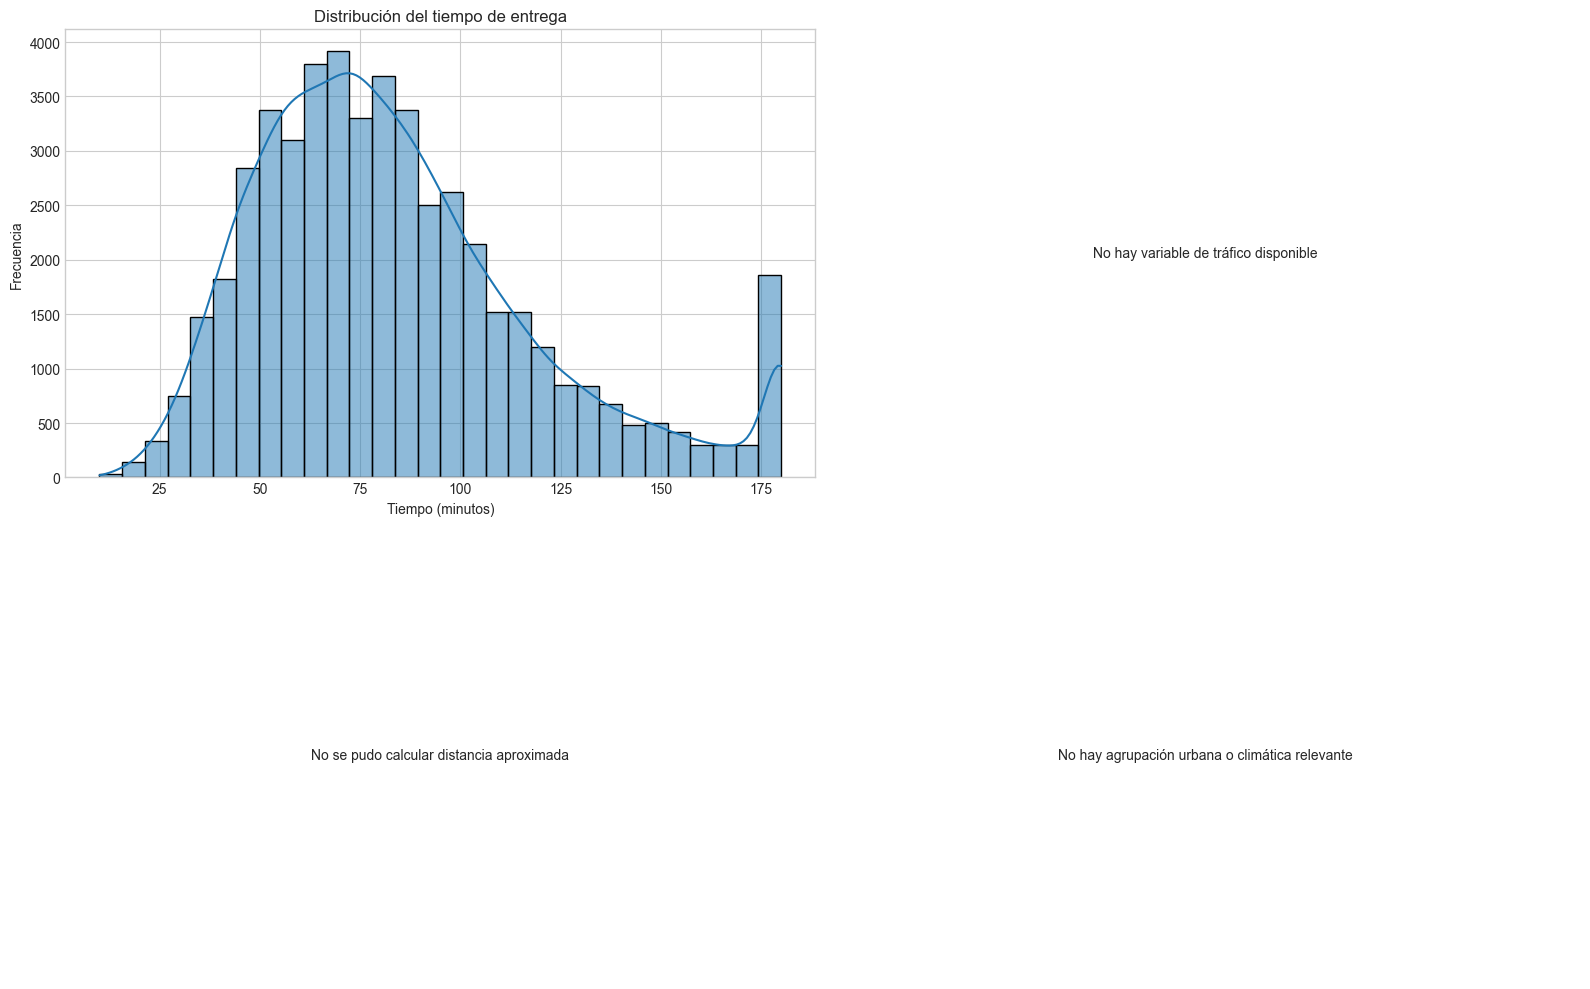

In [9]:
# --- Gráficos 1 a 4: análisis visual de la variable objetivo y relaciones clave ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Histograma del tiempo de entrega
sns.histplot(df['target_time'].dropna(), bins=30, kde=True, color='#1f77b4', ax=axes[0, 0])
axes[0, 0].set_title('Distribución del tiempo de entrega')
axes[0, 0].set_xlabel('Tiempo (minutos)')
axes[0, 0].set_ylabel('Frecuencia')

# 2. Boxplot por tráfico si existe
if traffic_col:
    order = ['Low', 'Medium', 'High', 'Very High'] if any(x.lower() in str(df[traffic_col].dropna().unique()).lower() for x in ['low', 'medium', 'high', 'very high']) else None
    sns.boxplot(data=df, x=traffic_col, y='target_time', order=order, palette='viridis', ax=axes[0, 1])
    axes[0, 1].set_title('Tiempo de entrega por nivel de tráfico')
    axes[0, 1].set_xlabel('Tráfico')
    axes[0, 1].set_ylabel('Tiempo (minutos)')
else:
    axes[0, 1].text(0.5, 0.5, 'No hay variable de tráfico disponible', ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_axis_off()

# 3. Relación distancia - tiempo si existe
if 'distance_km' in df.columns:
    sns.scatterplot(data=df, x='distance_km', y='target_time', alpha=0.55, color='#d62728', ax=axes[1, 0])
    axes[1, 0].set_title('Distancia aproximada vs tiempo de entrega')
    axes[1, 0].set_xlabel('Distancia (km)')
    axes[1, 0].set_ylabel('Tiempo (minutos)')
else:
    axes[1, 0].text(0.5, 0.5, 'No se pudo calcular distancia aproximada', ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_axis_off()

# 4. Promedio por ciudad o clima si existe
if city_col:
    city_summary = df.groupby(city_col)['target_time'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=city_summary.values, y=city_summary.index, palette='rocket', ax=axes[1, 1])
    axes[1, 1].set_title('Tiempo promedio por ciudad')
    axes[1, 1].set_xlabel('Tiempo medio (minutos)')
    axes[1, 1].set_ylabel('Ciudad')
elif weather_col:
    weather_summary = df.groupby(weather_col)['target_time'].mean().sort_values(ascending=False)
    sns.barplot(x=weather_summary.values, y=weather_summary.index, palette='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title('Tiempo promedio por clima')
    axes[1, 1].set_xlabel('Tiempo medio (minutos)')
    axes[1, 1].set_ylabel('Clima')
else:
    axes[1, 1].text(0.5, 0.5, 'No hay agrupación urbana o climática relevante', ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

# Comentario: si el tráfico o la distancia aumentan, el tiempo normalmente crece de forma clara.
# La relación no es lineal perfecta, pero estos patrones suelen ser los más útiles para explicar y predecir demoras operativas.

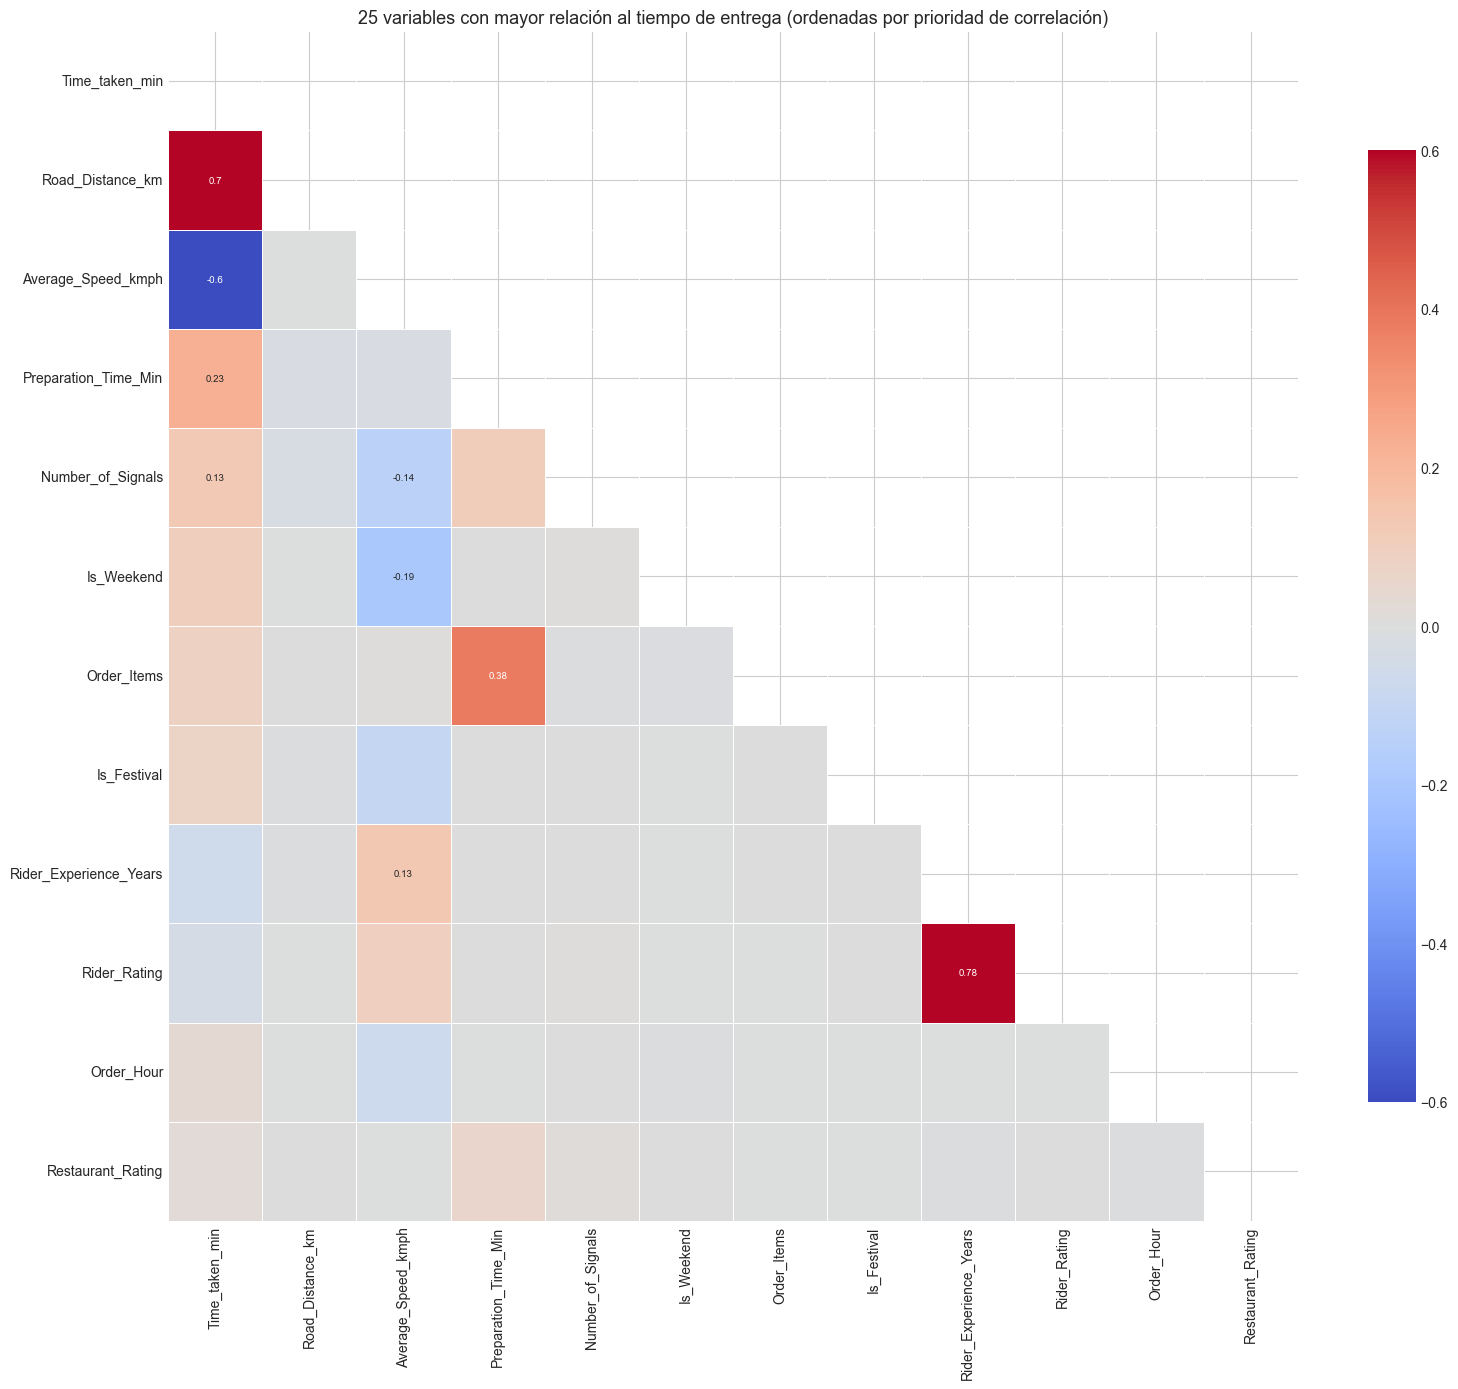

In [10]:
# --- Correlación de las 25 variables más relacionadas con la variable objetivo ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'target_time' in num_cols:
    num_cols.remove('target_time')

if len(num_cols) == 0:
    raise ValueError('No hay columnas numéricas para la correlación. Revisa el tipo de datos.')

corr_with_target = df[num_cols + ['target_time']].corr(numeric_only=True)['target_time'].drop('target_time').abs().sort_values(ascending=False)
ordered_cols = corr_with_target.head(25).index.tolist()

if len(ordered_cols) == 0:
    raise ValueError('No se encontraron variables numéricas relacionadas con el objetivo.')

corr_matrix = df[ordered_cols].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmin=-0.6,
    vmax=0.6,
    center=0,
    annot=np.where(np.abs(corr_matrix) >= 0.12, corr_matrix.round(2).astype(str), ''),
    fmt='',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'shrink': 0.8},
    annot_kws={'fontsize': 7}
)
plt.title('25 variables con mayor relación al tiempo de entrega (ordenadas por prioridad de correlación)', fontsize=13)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Comentario: esta matriz se ordena por fuerza de relación con la variable objetivo.
# En modelos de regresión, los valores más altos en valor absoluto son los candidatos más importantes para analizar primero.
# Los números aparecen solo cuando la correlación es suficientemente relevante para justificar atención.

## 2. Qué variables son más relevantes para este objetivo

Las columnas que más suelen aportar valor para predecir el tiempo de entrega son:

- Distancia estimada entre restaurante y destino.
- Nivel de tráfico o densidad vial.
- Condiciones del clima.
- Ciudad, barrio o zona de entrega.
- Tipo de pedido o modalidad de operación.
- Condiciones del vehículo o del repartidor.
- Tiempo de preparación, recogida y horario del pedido.

Lo más importante es filtrar variables de identidad o ruido:

- IDs y nombres del pedido/repartidor/restaurante.
- Datos no disponibles antes de la entrega.
- Columnas con alta cardinalidad que no tienen sentido como predictores si no se transforman bien.

## 3. Sesgo y desbalance del dataset respecto al objetivo

Para un problema de regresión, el concepto de desbalance no es exactamente el mismo que en clasificación. Aquí la clave es revisar la distribución del tiempo de entrega:

- Si la mayoría de los pedidos se concentran en un rango corto, el modelo puede aprender muy bien ese tramo y fallar en entregas atípicas.
- El sesgo puede aparecer por ciudad, tráfico, clima, tipo de pedido o condiciones del repartidor.
- Si una ciudad o un tipo de tráfico tiene pocas observaciones, el modelo puede generalizar mal para ese segmento.

Si se convierte el problema en clasificación, por ejemplo, entregas rápidas/medias/lentas, sí puede existir desbalance entre clases. En ese caso debe revisarse:

- proporción por clase,
- clase minoritaria,
- métricas por clase y no solo accuracy.

En términos prácticos, el riesgo real no es solo el desbalance, sino que el conjunto de datos tienda a reflejar ventanas operativas muy repetitivas y no represente bien los casos de alta demora. Por eso conviene revisar la distribución por tráfico, ciudad y condiciones climáticas antes de entrenar.

## 4. Recomendación final

La mejor primera estrategia es entrenar una regresión para predecir `Time_taken(min)`, porque conserva la información real del tiempo y permite usar métricas como MAE, RMSE y R².

Luego, si se quiere una versión más operativa, se puede convertir a clasificación de entregas rápidas/medias/lentas o a alerta de entrega tardía, siempre validando el balance por clase y evitando variables que solo se conocen después de la entrega.